In [1]:
import torch 
torch.cuda.is_available()

True

In [2]:
import sys
sys.path.append('../../utils')
from functions import * 
from importlib import reload
import sys

# Path to the Leaflet repository
PATH_TO_LEAFLET_REPO = '/gpfs/commons/home/kisaev/Leaflet/src/beta-binomial-mix/'
sys.path.append(PATH_TO_LEAFLET_REPO)

In [3]:
import pyro
import pyro.distributions as dist
from pyro.infer.autoguide import AutoDiagonalNormal, AutoGuideList, AutoDelta, AutoMultivariateNormal
from pyro.infer import SVI, Trace_ELBO, RenyiELBO, Predictive
from pyro.distributions import constraints
import matplotlib.pyplot as plt
import math
from importlib import reload
#from load_cluster_data import load_cluster_data
from betabinomo_mix_singlecells import *
#reload(betabinomo_mix_singlecells)
from cell_state_asign_consistency import *
#reload(cell_state_asign_consistency)
import load_cluster_data

import torch
import sklearn.manifold 
import plotnine as p9
import time
# indicate plot should be small 4 by 4
import plotnine as p9
from plotnine import ggplot, geom_point, aes, stat_smooth, facet_wrap, geom_violin, theme, element_blank, geom_text, geom_bar, geom_hline
import plotnine
from tqdm import tqdm
plotnine.options.figure_size = (4, 4)
import seaborn as sns
sns.set_theme(style="whitegrid")

/gpfs/commons/home/kisaev/.local/lib/python3.9/site-packages/statsmodels/compat/pandas.py:65: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.


### Settings and Load data

In [4]:
torch.manual_seed(42)

# set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

K = 50 # set to very high number 

float_type = { 
    "device" : device, 
    "dtype" : torch.float, # save memory
}

hypers = {
    "eta" : 1./K, 
    "alpha_prior" : 1, # karin had 0.65 
    "pi_prior" : 1 
}

print(hypers["eta"])

cuda
0.02


In [5]:
# this folder contains input data for each tissue cell type sample
input_files_folder = '/gpfs/commons/projects/CZI-tabula-sapiens/Leaflet-Analysis/Leaflet-Intron-Clusters/Muscle/'

# convert data to Leaflet required input formats 
final_data, coo_counts_sparse, coo_cluster_sparse, cell_ids_conversion, junction_ids_conversion = load_cluster_data.load_cluster_data(
    input_folder = input_files_folder, has_genes="yes") 

# add cluster to final_data 
final_data = final_data.merge(junction_ids_conversion, on=["junction_id_index"], how="left")

# still do preprocessing in scipy
import scipy.sparse as sp
indices = (final_data.cell_id_index, final_data.junction_id_index)
indices_np = np.stack(indices)
junc_counts = sp.coo_matrix((final_data.junc_count, indices))
cluster_counts = sp.coo_matrix((final_data.cluster_count, indices))

# sanity check that counts are saved in correct indices in sparse matrices
ind_random = np.random.randint(0, len(final_data))
print(final_data.iloc[ind_random])
print(junc_counts.toarray()[final_data.iloc[ind_random].cell_id_index, final_data.iloc[ind_random].junction_id_index])
print(cluster_counts.toarray()[final_data.iloc[ind_random].cell_id_index, final_data.iloc[ind_random].junction_id_index])

Reading in data from folder ...
/gpfs/commons/projects/CZI-tabula-sapiens/Leaflet-Analysis/Leaflet-Intron-Clusters/Muscle/
Finished reading in data from folder ...
['mesenchymal stem cell' 'macrophage' 't cell'
 'cd8-positive, alpha-beta t cell' 'tendon cell'
 'endothelial cell of lymphatic vessel' 'capillary endothelial cell'
 'endothelial cell of artery' 'fast muscle cell'
 'skeletal muscle satellite stem cell' 'slow muscle cell'
 'endothelial cell of vascular tree' 'mature nk t cell' 'pericyte cell'
 'mesothelial cell' 'cd4-positive, alpha-beta t cell' 'smooth muscle cell'
 'erythrocyte' 'mast cell']
5004
144381
                                       cell_id  Cluster  Cluster_Counts  \
0  B107909_A11_S239.homo.gencode.v30.ERCC.chrM      146             191   
1  B107909_A11_S239.homo.gencode.v30.ERCC.chrM      146             191   
2  B107909_A11_S239.homo.gencode.v30.ERCC.chrM      146             191   
3  B107909_A11_S239.homo.gencode.v30.ERCC.chrM      476              28   
4 

In [6]:
cell_index_tensor, junc_index_tensor, my_data = make_torch_data(final_data, **float_type)

The number of cells going into training data is:
5004
5004


/gpfs/commons/home/kisaev/Leaflet/src/beta-binomial-mix/betabinomo_mix_singlecells.py:333: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at ../aten/src/ATen/SparseCsrTensorImpl.cpp:53.)


In [7]:
simple_data = final_data[["cell_id_index", "Cluster", "cell_type", "junction_id_index", "juncratio", "junc_count", "cluster_count",  "junction_id", "gene_id"]]
# get true PSI for each Cluster 
simple_data.head()

,cell_id_index,Cluster,cell_type,junction_id_index,juncratio,junc_count,cluster_count,junction_id,gene_id
0,0,64526,capillary endothelial cell,8529,0.121212,32.0,264,11_20387774_20388018,ENSG00000185238.13
1,0,64526,capillary endothelial cell,8532,0.208333,55.0,264,11_20388154_20389743,ENSG00000185238.13
2,0,64526,capillary endothelial cell,8533,0.250000,66.0,264,11_20389826_20392210,ENSG00000185238.13
3,0,64526,capillary endothelial cell,8536,0.227273,60.0,264,11_20392260_20392896,ENSG00000185238.13
4,0,64526,capillary endothelial cell,8537,0.193182,51.0,264,11_20392999_20395802,ENSG00000185238.13


In [8]:
def quick_clust_plot(clust, simple_data):
    simple_data_junc = simple_data[simple_data["Cluster"] == clust]
    # make violin plot with jitter 
    print(simple_data_junc.cell_type.value_counts())
    print(simple_data_junc.gene_id.unique())
    print(simple_data_junc.junction_id.unique())
    plt.figuresize=(6, 6)
    sns.violinplot(data = simple_data_junc, x = "juncratio", y = "cell_type", hue="junction_id_index")
    # make xlim -1 to 1.1
    plt.xlim(-0.2, 1.2)
    # add sample_label to title 
    plt.title("cluster:" + str(clust), fontsize=16)
    # set x axis label to "Junction Usage Ratio (PSI)"
    plt.xlabel("Junction Usage Ratio (PSI)", fontsize=20)
    plt.ylabel("Cell Type Group", fontsize=20)
    # increase x and y tick label size to 14
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    plt.show()

In [9]:
junction_ids_conversion[junction_ids_conversion["Cluster"] == 4]

,junction_id_index,junction_id,Cluster,gene_id
1065028,63603,1_169803309_169804074,4,ENSG00000000460.17
1960947,63604,1_169803309_169804111,4,ENSG00000000460.17


mesenchymal stem cell                   14
skeletal muscle satellite stem cell      4
capillary endothelial cell               4
mature nk t cell                         2
cd8-positive, alpha-beta t cell          2
endothelial cell of lymphatic vessel     2
endothelial cell of vascular tree        2
Name: cell_type, dtype: int64
['ENSG00000000460.17']
['1_169803309_169804074' '1_169803309_169804111']


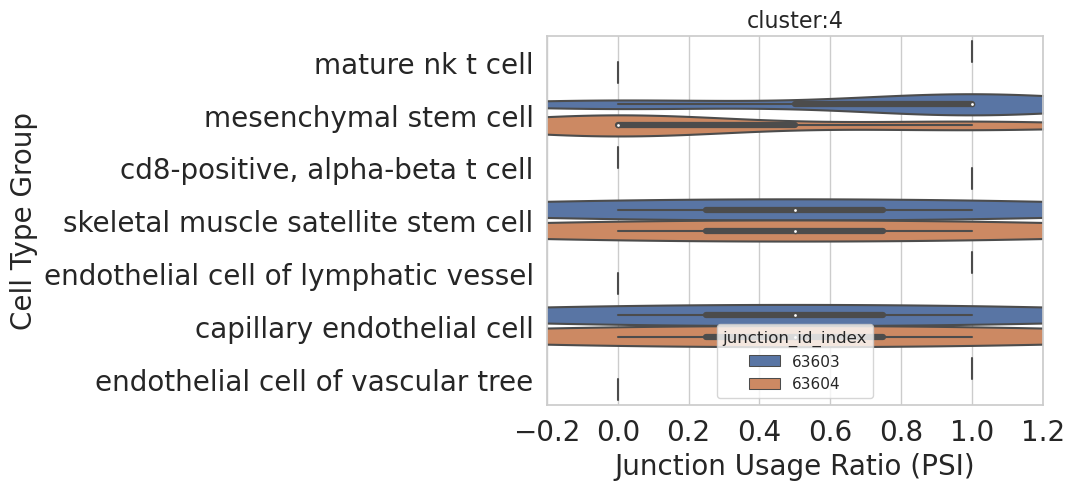

In [10]:
# let's visualize junction usage ratios for a given custer 
clust = 4
quick_clust_plot(clust, simple_data)

In [11]:
def my_log_prob(y_sparse, total_counts_sparse, pred):
    
    # Extract non-zero elements and their indices from y and total_counts
    y_indices = y_sparse._indices()
    y_values = y_sparse._values()

    total_counts_indices = total_counts_sparse._indices()
    total_counts_values = total_counts_sparse._values()

    # Ensure that y and total_counts align on the same indices
    # This step might require custom logic based on how y and total_counts are related
    # For simplicity, assuming they align directly (which might not be the case)
    assert torch.equal(y_indices, total_counts_indices)

    # Compute log probabilities at these indices
    log_probs = dist.Binomial(total_counts_values, pred[y_indices[0], y_indices[1]]).log_prob(y_values)

    # Sum the log probabilities
    return log_probs.sum()

In [12]:
torch.set_default_tensor_type('torch.cuda.FloatTensor')

def model(y, total_counts, K):
    N, P = y.shape

    a = pyro.sample("a", dist.Gamma(1., 1.).expand([P]).to_event(1))
    b = pyro.sample("b", dist.Gamma(1., 1.).expand([P]).to_event(1))

    psi_dist = dist.Beta(a, b).expand([K, P]).to_event(2)
    psi = pyro.sample("psi", psi_dist)

    pi = pyro.sample("pi", dist.Dirichlet(torch.ones(K) / K))
    conc = pyro.sample("conc", dist.Gamma(1, 1))

    with pyro.plate('data1', N):
        assign_dist = dist.Dirichlet(pi * conc)
        assign = pyro.sample("assign", assign_dist)

    pred = torch.mm(assign, psi)

    # Use custom log probability
    # This used to be
    #with pyro.plate('dims', P): # This outer plate indicates that the dimensions (junctions) are independent of each other across all data points (cells).
        #with pyro.plate('data', N): #This inner plate indicates that the cells are independent of each other. Within each cell, you have multiple junctions (dimensions), and the inner plate makes it clear that you're modeling each cell's data independently.
              #obs = pyro.sample('obs', dist.Binomial(total_counts, pred), obs=y)
    log_prob = my_log_prob(y, total_counts, pred)
    pyro.factor("obs", log_prob.sum())

In [13]:
def fit(y, total_counts, K, guide):
    adam = pyro.optim.Adam({"lr": 0.05})
    svi = SVI(model, guide, adam, loss=Trace_ELBO())
    pyro.clear_param_store()
    losses = []
    for j in range(500):
        loss = svi.step(y, total_counts, K)
        losses.append(loss)
        if j % 10 == 0:
            print(f"Epoch {j}, Loss: {loss}")
        torch.cuda.empty_cache()  # Attempt to free unused memory
    return losses

In [14]:
indices = torch.tensor(final_data[['cell_id_index', 'junction_id_index']].to_numpy().T, dtype=torch.long)
values = torch.tensor(final_data['junc_count'].to_numpy(), dtype=torch.float)
# Determine the size of the tensor
num_cells = final_data['cell_id_index'].max() + 1
num_junctions = final_data['junction_id_index'].max() + 1
size = (num_cells, num_junctions)
# Create a sparse tensor
y_tensor = torch.sparse_coo_tensor(indices, values, size)

In [15]:
indices_counts = torch.tensor(final_data[['cell_id_index', 'junction_id_index']].to_numpy().T, dtype=torch.long)
values_counts = torch.tensor(final_data['cluster_count'].to_numpy(), dtype=torch.float)
# Determine the size of the tensor
num_cells_counts = final_data['cell_id_index'].max() + 1
num_junctions_counts = final_data['junction_id_index'].max() + 1
size_counts = (num_cells_counts, num_junctions_counts)
# Create a sparse tensor
total_counts_tensor = torch.sparse_coo_tensor(indices_counts, values_counts, size_counts)

In [16]:
K = 5 # num factors
J = len(total_counts_tensor[0])
C = len(total_counts_tensor)
print(C, J, K)

guide = AutoDiagonalNormal(model)
print(guide)

5004 144382 5
AutoDiagonalNormal()


In [17]:
losses = fit(y_tensor, total_counts_tensor, K, guide)
plt.plot(losses, label = "Diagonal variational posterior")

OutOfMemoryError: CUDA out of memory. Tried to allocate 2.69 GiB (GPU 0; 7.92 GiB total capacity; 5.83 GiB already allocated; 1.58 GiB free; 6.19 GiB reserved in total by PyTorch) If reserved memory is >> allocated memory try setting max_split_size_mb to avoid fragmentation.  See documentation for Memory Management and PYTORCH_CUDA_ALLOC_CONF
Trace Shapes:                     
 Param Sites:                     
Sample Sites:                     
       a dist      | 144382       
        value      | 144382       
       b dist      | 144382       
        value      | 144382       
     psi dist      |      5 144382
        value      |      5 144382
      pi dist      |      5       
        value      |      5       
    conc dist      |              
        value      |              
  assign dist 5004 |      5       
        value 5004 |      5       
Trace Shapes:
 Param Sites:
Sample Sites:

In [ ]:
# Sample from the guide (posterior)
guide_trace = pyro.poutine.trace(guide).get_trace(y_tensor, total_counts_tensor, K)

In [ ]:
# Extract the latent variables
latent_vars = {name: node["value"].detach().cpu().numpy() for name, node in guide_trace.nodes.items() if node["type"] == "sample"}

In [ ]:
latent_vars["pi"]

In [ ]:
latent_vars["conc"]

In [ ]:
# can we plot assign probabilityies for each cell
assign_post = latent_vars["assign"]
assign_post

In [ ]:
import umap
# Step 1: Run UMAP
reducer = umap.UMAP()
embedding = reducer.fit_transform(assign_post)  # Reducing to 2 dimensions

In [ ]:
# Step 2: Prepare cell type labels for coloring
# Assuming cell_ids_conversion is a dictionary mapping indices to cell types
# Convert cell type labels to a list in the same order as your data
cell_types = cell_ids_conversion['cell_type'].tolist()

In [ ]:
print(cell_ids_conversion.cell_type.value_counts())

In [ ]:
top_three_cell_types = ['Neutrophil', 'Sorted Myeloid', 'Endothelial']
cell_types = cell_ids_conversion['cell_type'].apply(lambda x: x if x in top_three_cell_types else 'Other').tolist()

In [ ]:
# Plotting
plt.figure(figsize=(7, 7))
sns.scatterplot(
    x=embedding[:, 0], 
    y=embedding[:, 1], 
    hue=cell_types,
    alpha=0.6,
    palette=sns.color_palette("Set3", len(top_three_cell_types) + 1),  # +1 for 'Other' category
    legend='full'
)
plt.title("UMAP Projection of assign_post Colored by Cell Type")
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.legend(title='Cell Type', bbox_to_anchor=(1.05, 1), loc=2)
plt.show()

In [ ]:
plt.hist(latent_vars["assign"].flatten())

In [ ]:
# Create a color palette for the cell types
cell_type_palette = sns.color_palette("hsv", len(set(cell_types)))
cell_type_palette[0] = "grey"

# Map cell types to colors
row_colors = [cell_type_palette[top_three_cell_types.index(ct)] if ct in top_three_cell_types else cell_type_palette[-1] for ct in cell_types]

In [ ]:
cell_type_palette

In [ ]:
# Generate the clustermap with row colors
sns.clustermap(assign_post, cmap="Blues", figsize=(12, 12),
              row_colors=row_colors,  # Using a list instead of a DataFrame
               yticklabels=False)  # Hide y-axis labels for clarity

plt.show()

In [ ]:
# Create a custom legend for the cell types
# Here, we use the cell_type_palette and top_three_cell_types
legend_handles = [plt.Line2D([0], [0], color=color, lw=4) for color in cell_type_palette]
legend_labels = top_three_cell_types + ['Other']

# Add the legend to the plot
plt.legend(handles=legend_handles, labels=legend_labels, title='Cell Type',
           bbox_to_anchor=(1, 1), loc='upper left')